In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_path = 'dataset/images/airplane/'
annotations_path = 'dataset/annotations/airplane.csv'

In [3]:
ann_df = pd.read_csv(annotations_path)

In [4]:
ann_df

,image_name,x1,y1,x2,y2
0,image_0001.jpg,49,30,349,137
1,image_0002.jpg,59,35,342,153
2,image_0003.jpg,47,36,331,135
3,image_0004.jpg,47,24,342,141
4,image_0005.jpg,48,18,339,146
...,...,...,...,...,...
795,image_0796.jpg,57,27,356,118
796,image_0797.jpg,56,25,350,110
797,image_0798.jpg,59,25,354,110
798,image_0799.jpg,49,26,347,116


In [5]:
file_index = 1
file_name = ann_df['image_name'].iloc[file_index]

In [6]:
img_path = os.path.join(data_path,file_name)

In [7]:
img_path

'dataset/images/airplane/image_0002.jpg'

In [8]:
img = cv2.cvtColor(cv2.imread(img_path),cv2.COLOR_BGR2RGB)

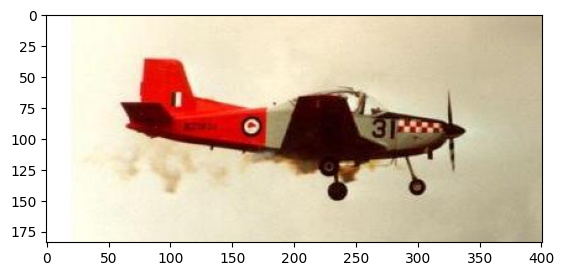

In [9]:
plt.imshow(img)
plt.show()

In [10]:
ann = ann_df[ann_df['image_name'] == file_name].iloc[0,1:].tolist()

In [11]:
ann

[59, 35, 342, 153]

In [12]:
img_ann = cv2.rectangle(img.copy(),ann[:2],ann[2:],color=(0,0,255),thickness=2)

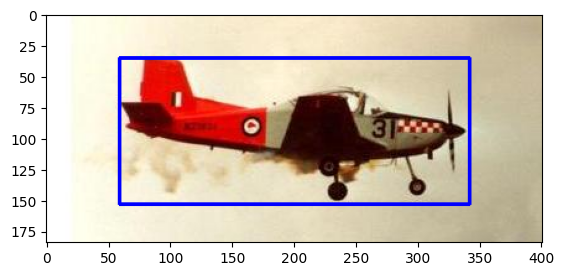

In [13]:
plt.imshow(img_ann)
plt.show()

In [14]:
img_resize = cv2.resize(img.copy(),(224,224))

In [15]:
img_resize_ann = cv2.rectangle(img_resize.copy(),ann[:2],ann[2:],color=(0,0,255),thickness=2)

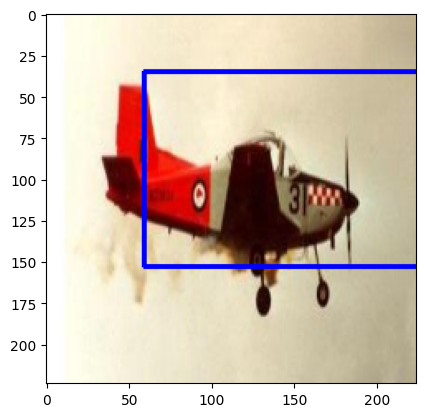

In [16]:
plt.imshow(img_resize_ann)
plt.show()

In [17]:
h,w,_ = img.shape

In [18]:
ann[0] = ann[0] / w
ann[1] = ann[1] / h
ann[2] = ann[2] / w
ann[3] = ann[3] / h

In [19]:
ann

[0.14713216957605985,
 0.19021739130434784,
 0.8528678304239401,
 0.8315217391304348]

In [20]:
ann[0] = int(ann[0] * 224)
ann[1] = int(ann[1] * 224)
ann[2] = int(ann[2] * 224)
ann[3] = int(ann[3] * 224)

In [21]:
ann

[32, 42, 191, 186]

In [22]:
img_resize_ann2 = cv2.rectangle(img_resize.copy(),ann[:2],ann[2:],color=(0,0,255),thickness=2)
img_resize_ann2 = cv2.putText(img_resize_ann2,'airplane',(ann[0],ann[1]-5),cv2.FONT_HERSHEY_COMPLEX,0.6,color=(0,0,255))

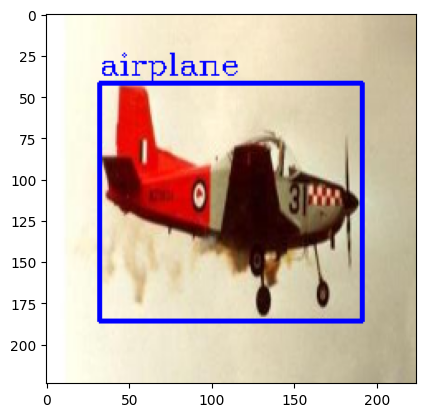

In [23]:
plt.imshow(img_resize_ann2)
plt.show()